In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("careescapes_dental_competitiveness_dataset.csv")

# 只分析 Single Dental Implant
implant_df = df[df["Procedure"] == "Single Dental Implant"].copy()

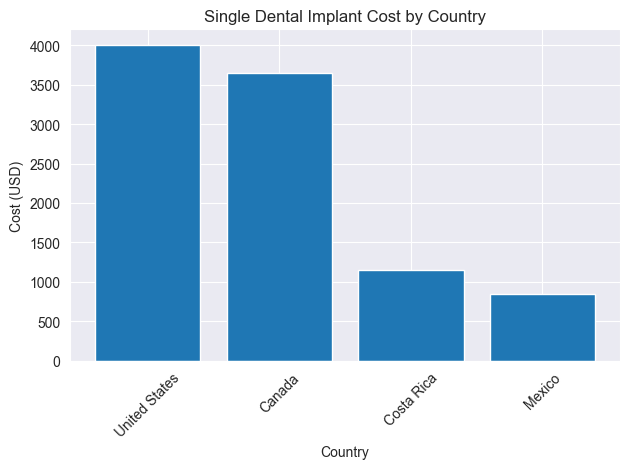

In [2]:
plt.figure()

plt.bar(implant_df["Country"], implant_df["Cost_Mid_USD"])

plt.title("Single Dental Implant Cost by Country")
plt.xlabel("Country")
plt.ylabel("Cost (USD)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

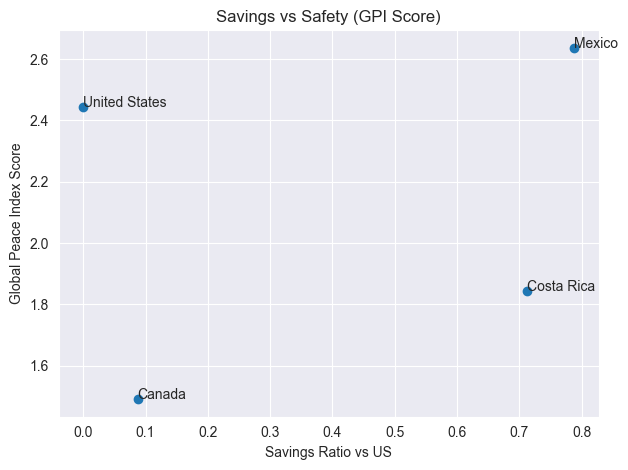

In [3]:
plt.figure()

x = implant_df["Savings_Ratio_vs_US"]
y = implant_df["GPI_2025_Score"]

plt.scatter(x, y)

for i in range(len(implant_df)):
    plt.text(x.iloc[i], y.iloc[i], implant_df["Country"].iloc[i])

plt.title("Savings vs Safety (GPI Score)")
plt.xlabel("Savings Ratio vs US")
plt.ylabel("Global Peace Index Score")

plt.tight_layout()
plt.show()

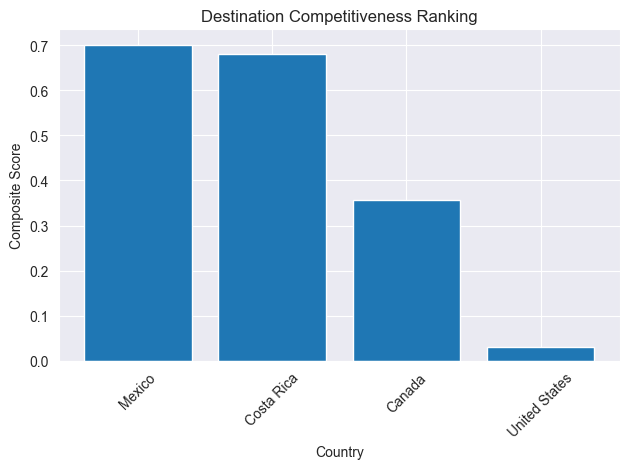

In [4]:
ranking_df = implant_df.copy()

# 标准化 savings
ranking_df["Savings_Scaled"] = (
    ranking_df["Savings_Ratio_vs_US"] - ranking_df["Savings_Ratio_vs_US"].min()
) / (
    ranking_df["Savings_Ratio_vs_US"].max() - ranking_df["Savings_Ratio_vs_US"].min()
)

# 安全指标（GPI 越低越好）
ranking_df["Safety_Index"] = 1 / ranking_df["GPI_2025_Score"]

ranking_df["Safety_Scaled"] = (
    ranking_df["Safety_Index"] - ranking_df["Safety_Index"].min()
) / (
    ranking_df["Safety_Index"].max() - ranking_df["Safety_Index"].min()
)

# JCI 标准化（缺失填0）
ranking_df["JCI_Count_Approx"] = ranking_df["JCI_Count_Approx"].fillna(0)

ranking_df["JCI_Scaled"] = (
    ranking_df["JCI_Count_Approx"] - ranking_df["JCI_Count_Approx"].min()
) / (
    ranking_df["JCI_Count_Approx"].max() - ranking_df["JCI_Count_Approx"].min()
)

# 加权评分
ranking_df["Competitiveness_Score"] = (
    0.5 * ranking_df["Savings_Scaled"] +
    0.3 * ranking_df["Safety_Scaled"] +
    0.2 * ranking_df["JCI_Scaled"]
)

ranking_df = ranking_df.sort_values("Competitiveness_Score", ascending=False)

plt.figure()

plt.bar(ranking_df["Country"], ranking_df["Competitiveness_Score"])

plt.title("Destination Competitiveness Ranking")
plt.xlabel("Country")
plt.ylabel("Composite Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()